<a href="https://colab.research.google.com/github/DebarghaSamanta/Face-detector-/blob/main/Emotion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download ananthu017/emotion-detection-fer

Dataset URL: https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer
License(s): CC0-1.0
  0% 0.00/65.2M [00:00<?, ?B/s]
100% 65.2M/65.2M [00:00<00:00, 1.28GB/s]


In [ ]:
import zipfile
zipfileref = zipfile.ZipFile('/content/emotion-detection-fer.zip', 'r')
zipfileref.extractall()
zipfileref.close()

In [ ]:
train_dir = '/content/train'
test_dir = '/content/test'

Preproccesing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(horizontal_flip=True,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   zoom_range=0.2,
                                   rescale=1./255,
                                   validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1/255)
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(48,48),
                                                    batch_size=64,
                                                    class_mode='categorical',
                                                    subset='training',
                                                    seed = 12,
                                                    shuffle = True)
validation_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(48,48),
                                                    batch_size=64,
                                                    class_mode='categorical',
                                                    subset='validation',
                                                    seed = 12,
                                                    shuffle = True)
test_generator = test_datagen.flow_from_directory(test_dir,
                                                    target_size=(48,48),
                                                    batch_size=64,
                                                    class_mode='categorical',
                                                    seed = 12)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization,Conv2D,MaxPooling2D,Concatenate
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l1, l2
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.applications import VGG16

In [ ]:
model = VGG16(input_shape=(48,48,3),
              include_top=False,weights="imagenet")
for layer in model.layers:
  layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
feature_extractor = Model(inputs=model.input, outputs=model.get_layer('block4_pool').output)
model_final = Sequential([
    feature_extractor,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

In [ ]:
model_final.compile(optimizer=Adam(learning_rate=0.0001,weight_decay=1e-6),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early = EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True
)

In [ ]:
history = model_final.fit(train_generator,epochs=30,batch_size=64,validation_data=validation_generator,callbacks=[early])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.2147 - loss: 2.9771 - val_accuracy: 0.3259 - val_loss: 1.6987
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.2930 - loss: 1.7457 - val_accuracy: 0.3456 - val_loss: 1.6447
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3167 - loss: 1.7036 - val_accuracy: 0.3679 - val_loss: 1.6096
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.3403 - loss: 1.6686 - val_accuracy: 0.3773 - val_loss: 1.5901
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.3504 - loss: 1.6472 - val_accuracy: 0.3996 - val_loss: 1.5707
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3635 - loss: 1.6135 - val_accuracy: 0.4116 - val_loss: 1.5494
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3726 - loss: 1.6105 - val_accuracy: 0.4121 - val_loss: 1.5352
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.3758 - loss: 1.5931 -

In [ ]:
history = model_final.fit(train_generator,epochs=30,batch_size=64,validation_data=validation_generator,callbacks=[early])

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4413 - loss: 1.4554 - val_accuracy: 0.4726 - val_loss: 1.3905
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4376 - loss: 1.4612 - val_accuracy: 0.4726 - val_loss: 1.3998
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4359 - loss: 1.4614 - val_accuracy: 0.4651 - val_loss: 1.4069
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4403 - loss: 1.4567 - val_accuracy: 0.4605 - val_loss: 1.4095
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.4383 - loss: 1.4587 - val_accuracy: 0.4659 - val_loss: 1.4066
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4411 - loss: 1.4441 - val_accuracy: 0.4700 - val_loss: 1.3961


In [ ]:
def FER_Model(input_shape=(48, 48, 3)):
    num_classes = 7

    # Input layer
    inputs = Input(shape=input_shape, name='input')

    # 1st Block
    x = Conv2D(64, kernel_size=3, activation='relu', padding='same', name='conv1_1')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, kernel_size=3, activation='relu', padding='same', name='conv1_2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
    x = Dropout(0.3, name='drop1')(x)

    # 2nd Block
    x = Conv2D(128, kernel_size=3, activation='relu', padding='same', name='conv2_1')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, kernel_size=3, activation='relu', padding='same', name='conv2_2')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, kernel_size=3, activation='relu', padding='same', name='conv2_3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    x = Dropout(0.3, name='drop2')(x)

    # 3rd Block
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv3_1')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv3_2')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv3_3')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv3_4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool3')(x)
    x = Dropout(0.3, name='drop3')(x)

    # 4th Block
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv4_1')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv4_2')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv4_3')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, kernel_size=3, activation='relu', padding='same', name='conv4_4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool4')(x)
    x = Dropout(0.3, name='drop4')(x)

    # 5th Block
    x = Conv2D(512, kernel_size=3, activation='relu', padding='same', name='conv5_1')(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, kernel_size=3, activation='relu', padding='same', name='conv5_2')(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, kernel_size=3, activation='relu', padding='same', name='conv5_3')(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, kernel_size=3, activation='relu', padding='same', name='conv5_4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool5')(x)
    x = Dropout(0.3, name='drop5')(x)

    # Flatten + Dense Output
    x = Flatten(name='flatten')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    # Build Model
    model = Model(inputs=inputs, outputs=outputs, name='FER_Model')

    model.summary()
    return model

In [ ]:
model = FER_Model()

# Use 'learning_rate' instead of deprecated 'lr' and avoid 'decay' (use schedules if needed)
opt = Adam(learning_rate=1e-4)

model.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

Model: "FER_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_3 (Conv2D)                │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_3 (Conv2D)                │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 13,115,079 (50.03 MB)

 Trainable params: 13,105,863 (49.99 MB)

 Non-trainable params: 9,216 (36.00 KB)

In [ ]:
history = model.fit(train_generator,
                     batch_size=64,
                    epochs=55,
                    verbose=1,
                    validation_data=validation_generator,callbacks=[early])

Epoch 1/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 151ms/step - accuracy: 0.1953 - loss: 2.8513 - val_accuracy: 0.2496 - val_loss: 1.8291
Epoch 2/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.2298 - loss: 1.9539 - val_accuracy: 0.2576 - val_loss: 1.8194
Epoch 3/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.2404 - loss: 1.8368 - val_accuracy: 0.2486 - val_loss: 1.8220
Epoch 4/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.2525 - loss: 1.7998 - val_accuracy: 0.2534 - val_loss: 1.8403
Epoch 5/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.2603 - loss: 1.7804 - val_accuracy: 0.2500 - val_loss: 1.8121
Epoch 6/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.2622 - loss: 1.7766 - val_accuracy: 0.2548 - val_loss: 1.8338
Epoch 7/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.2757 - loss: 1.7573 - val_accuracy: 0.2576 - val_loss: 1.8685
Epoch 8/55
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.2945 - loss: 1

In [ ]:
model.save('model.h5')
print("Done")

Done


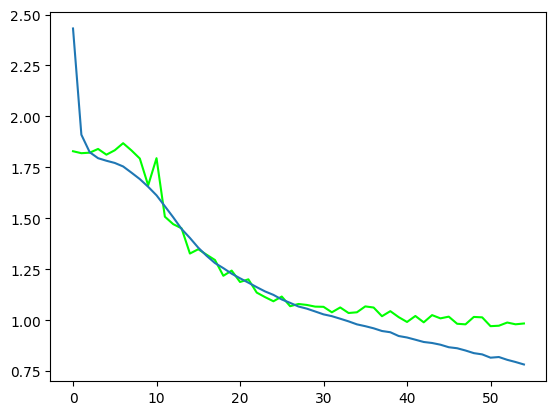

In [ ]:
plt.plot(history.history['val_loss'],color='#00FF00')
plt.plot(history.history['loss'])

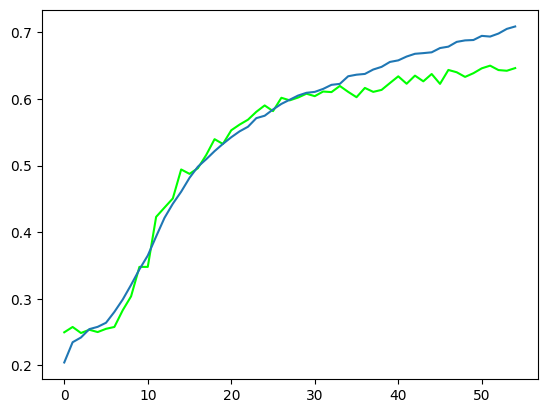

In [ ]:
plt.plot(history.history['val_accuracy'],color='#00FF00')
plt.plot(history.history['accuracy'])

In [ ]:

import numpy as np
model.evaluate(test_generator)
preds = model.predict(test_generator)
y_preds = np.argmax(preds , axis = 1 )
y_test = np.array(test_generator.labels)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6607 - loss: 0.9432
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


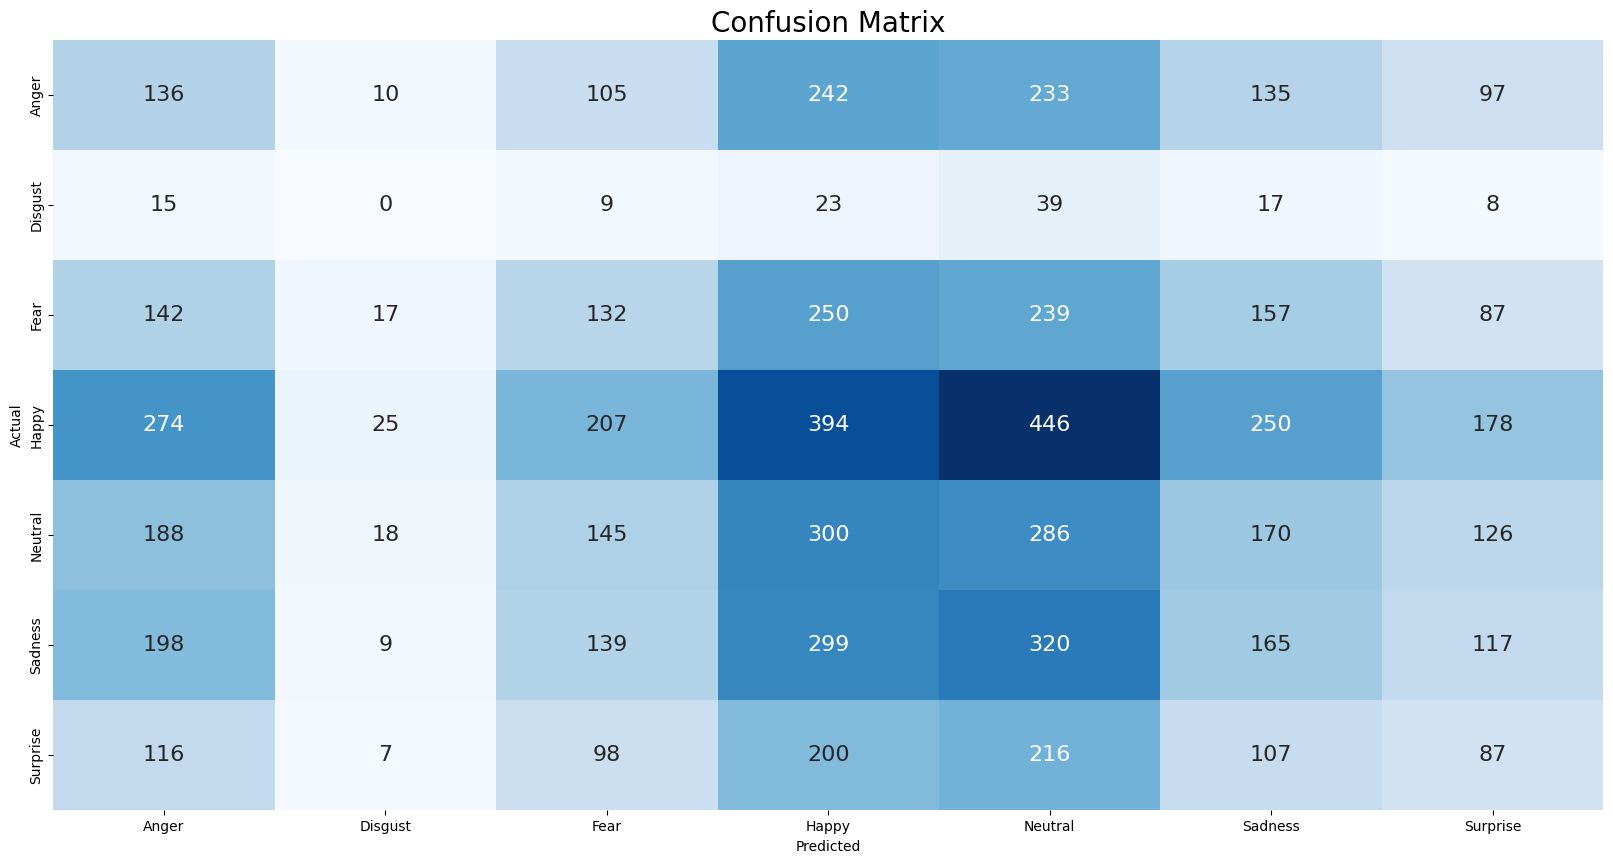

In [ ]:
import pandas as pd
import seaborn as sns
CLASS_LABELS  = ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]
cm_data = confusion_matrix(y_test , y_preds)
cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.13      0.14      0.13       958
           1       0.00      0.00      0.00       111
           2       0.16      0.13      0.14      1024
           3       0.23      0.22      0.23      1774
           4       0.16      0.23      0.19      1233
           5       0.16      0.13      0.15      1247
           6       0.12      0.10      0.11       831

    accuracy                           0.17      7178
   macro avg       0.14      0.14      0.14      7178
weighted avg       0.17      0.17      0.17      7178



add classweight balanced,ov